# BREST: executable spatial prediction and bulk completion demo

This notebook runs a compact, end-to-end BREST workflow:

1. load cell-level histology features and spatial coordinates;
2. build per-spot Delaunay graphs;
3. train the **GAT + global Transformer + gene-query** model;
4. evaluate spatial expression using **Overall PCC** and **Gene PCC**; and
5. complete held-out genes with a bulk covariance prior using
   **Direct**, **BLUP-true**, and **BLUP-pred**.

The bundled cohort is deterministic and fully synthetic so the repository does
not redistribute patient data, HEST imagery, or H0-mini weights. It preserves
the shapes and interfaces of the real pipeline, including 1,536-dimensional
cell features and COAD-panel gene labels. Its scores are a software smoke test,
**not benchmark results**.

Expected runtime is under one minute on a recent GPU and a few minutes on CPU.

## 1. Setup

Run this notebook either from the repository root or from `demo/`. The path
logic below is relative and contains no machine-specific directories.

In [1]:
from pathlib import Path
import platform
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch_geometric
from IPython.display import display

HERE = Path.cwd().resolve()
if (HERE / "brest").is_dir():
    ROOT = HERE
elif (HERE.parent / "brest").is_dir():
    ROOT = HERE.parent
else:
    raise RuntimeError("Run the notebook from the BREST repository root or demo directory.")
sys.path.insert(0, str(ROOT))

from demo.demo_utils import (
    build_demo_graphs,
    evaluate_bulk_completion,
    fit_demo_model,
    load_demo_data,
)

SEED = 42
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
DATA_PATH = ROOT / "demo" / "demo_data" / "brest_toy_coad.npz"

plt.style.use("seaborn-v0_8-whitegrid")
warnings.filterwarnings("ignore", message="enable_nested_tensor is True")
print("Repository root detected.")
print(f"Device:     {DEVICE}")
print(f"Python:     {platform.python_version()}")
print(f"PyTorch:    {torch.__version__}")
print(f"PyG:        {torch_geometric.__version__}")

Repository root detected.
Device:     cuda:0
Python:     3.12.9
PyTorch:    2.6.0+cu124
PyG:        2.6.1


## 2. Inspect the demonstration cohort

Each spot is a bag of six cells. BREST constructs a Delaunay graph inside each
bag, predicts expression for each cell with the gene-query head, then averages
those predictions to obtain the spot output. Two slides are used for fitting,
one for validation-based checkpoint selection, and one remains untouched for
the final test.

In [2]:
data = load_demo_data(DATA_PATH)
genes = data["genes"].tolist()
graphs = build_demo_graphs(data)

summary = pd.DataFrame(
    [
        ("slides", len(data["slide_names"])),
        ("spots", len(data["expression"])),
        ("cells", len(data["cell_features"])),
        ("cells per spot", int(np.diff(data["bag_ptr"]).mean())),
        ("cell feature dimension", data["cell_features"].shape[1]),
        ("panel genes", len(genes)),
        ("synthetic bulk samples", len(data["bulk_expression"])),
        ("held-out demo genes", len(data["heldout_indices"])),
    ],
    columns=["Item", "Value"],
)
display(summary)
print("Split:", dict(zip(data["slide_names"].tolist(), data["slide_splits"].tolist())))
print("Held-out genes:", ", ".join(data["genes"][data["heldout_indices"]].tolist()))

,Item,Value
0,slides,4
1,spots,256
2,cells,1536
3,cells per spot,6
4,cell feature dimension,1536
5,panel genes,64
6,synthetic bulk samples,256
7,held-out demo genes,12


Split: {'train_A': 'train', 'train_B': 'train', 'validation': 'validation', 'test': 'test'}
Held-out genes: ACTN4, CTNNB1, DSG1, ENO1, EZR, FGFR3, FLNA, HIF1A, ITGB4, JUP, TP63, VIM


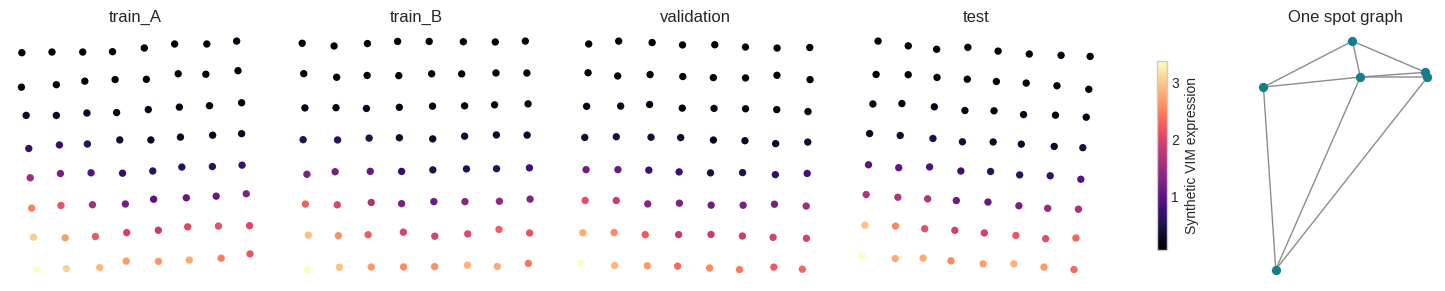

In [3]:
# Spatial expression and one cell-level Delaunay graph.
marker = "VIM"
marker_idx = genes.index(marker)
fig, axes = plt.subplots(1, 5, figsize=(15, 2.8), constrained_layout=True)

for slide_idx, (slide_name, ax) in enumerate(zip(data["slide_names"], axes[:4])):
    rows = data["slide_index"] == slide_idx
    scatter = ax.scatter(
        data["spot_coords"][rows, 0],
        -data["spot_coords"][rows, 1],
        c=data["expression"][rows, marker_idx],
        cmap="magma",
        s=28,
        linewidths=0,
    )
    ax.set_title(str(slide_name))
    ax.set_aspect("equal")
    ax.set_axis_off()
fig.colorbar(scatter, ax=axes[:4], label=f"Synthetic {marker} expression", shrink=0.75)

graph = graphs[0]
edge_index = graph.edge_index.numpy()
for source, target in edge_index.T:
    if source < target:
        axes[4].plot(
            graph.pos[[source, target], 0],
            -graph.pos[[source, target], 1],
            color="#8c8c8c",
            linewidth=1,
            zorder=1,
        )
axes[4].scatter(graph.pos[:, 0], -graph.pos[:, 1], color="#167d8d", s=32, zorder=2)
axes[4].set_title("One spot graph")
axes[4].set_aspect("equal")
axes[4].set_axis_off()
plt.show()

## 3. Train BREST on the small cohort

The public demo uses the same components as the full model but a reduced
configuration (`hidden_dim=64`, one GAT layer, one Transformer layer, five
epochs) to keep the notebook quick. Full experiments use the canonical
`hidden_dim=256`, two-layer configuration and the complete folds.

Targets are standardized using the training slides only. The checkpoint is
selected by validation Gene PCC; the test slide is evaluated once afterward.

Parameters: 196,673
Selected epoch: 5 (validation Gene PCC)


,Overall PCC,Gene PCC
BREST test,0.937,0.898


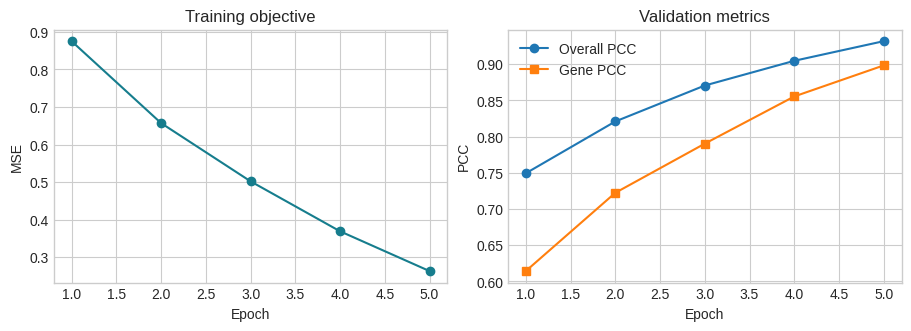

In [4]:
run = fit_demo_model(
    data,
    device=DEVICE,
    seed=SEED,
    epochs=5,
    batch_size=32,
    learning_rate=2e-3,
)

history = pd.DataFrame(run["history"])
print(f"Parameters: {run['parameter_count']:,}")
print(f"Selected epoch: {run['best_epoch']} (validation Gene PCC)")
display(pd.DataFrame([run["test_metrics"]], index=["BREST test"]).round(3))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), constrained_layout=True)
axes[0].plot(history["epoch"], history["train_mse"], marker="o", color="#167d8d")
axes[0].set(xlabel="Epoch", ylabel="MSE", title="Training objective")
axes[1].plot(history["epoch"], history["validation_overall_pcc"], marker="o", label="Overall PCC")
axes[1].plot(history["epoch"], history["validation_gene_pcc"], marker="s", label="Gene PCC")
axes[1].set(xlabel="Epoch", ylabel="PCC", title="Validation metrics")
axes[1].legend(frameon=False)
plt.show()

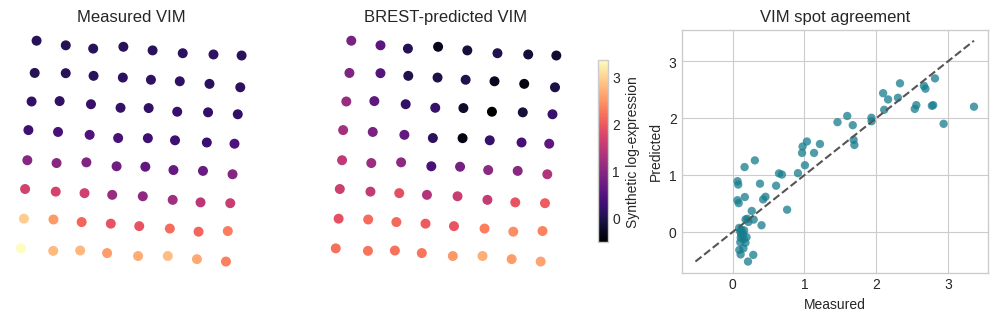

In [5]:
# Spatial test-slide prediction for a panel gene.
test_rows = run["indices"]["test"]
xy = data["spot_coords"][test_rows]
target = run["test_target"][:, marker_idx]
prediction = run["test_prediction"][:, marker_idx]
limits = (min(target.min(), prediction.min()), max(target.max(), prediction.max()))

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.1), constrained_layout=True)
for ax, values, title in zip(
    axes[:2],
    [target, prediction],
    [f"Measured {marker}", f"BREST-predicted {marker}"],
):
    scatter = ax.scatter(xy[:, 0], -xy[:, 1], c=values, cmap="magma", s=38, vmin=limits[0], vmax=limits[1])
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_axis_off()
axes[2].scatter(target, prediction, color="#167d8d", alpha=0.75, edgecolors="none")
axes[2].plot(limits, limits, linestyle="--", color="#555555")
axes[2].set(xlabel="Measured", ylabel="Predicted", title=f"{marker} spot agreement")
fig.colorbar(scatter, ax=axes[:2], shrink=0.75, label="Synthetic log-expression")
plt.show()

## 4. Complete held-out genes with the bulk prior

Let \(O\) denote observed genes and \(H\) the fixed held-out genes. The external
bulk reference estimates the standardized gene covariance \(\Sigma\). BREST
uses the closed-form Gaussian BLUP operator

\[
\widetilde{Y}_H =
\widetilde{Y}_O
(\Sigma_{OO}+\lambda I)^{-1}\Sigma_{OH}.
\]

The comparison follows the fixed held-out-gene protocol:

- **Direct**: BREST predicts \(H\) directly from histology features;
- **BLUP-true**: BLUP receives measured \(O\) with \(\lambda=10\), an oracle reference;
- **BLUP-pred**: BLUP receives BREST-predicted \(O\) with the
  prediction-calibrated \(\lambda_{\mathrm{pred}}=1\).

All three methods are evaluated on exactly the same held-out genes. Overall PCC
is the flattened Pearson correlation in restored log-expression space; Gene PCC
is the mean column-wise Pearson correlation. Prediction calibration uses no
held-out-gene labels and adds no trainable parameters.

,Overall PCC,Gene PCC
Method,,
Direct,0.940,0.875
BLUP-true,0.922,0.887
BLUP-pred,0.945,0.875


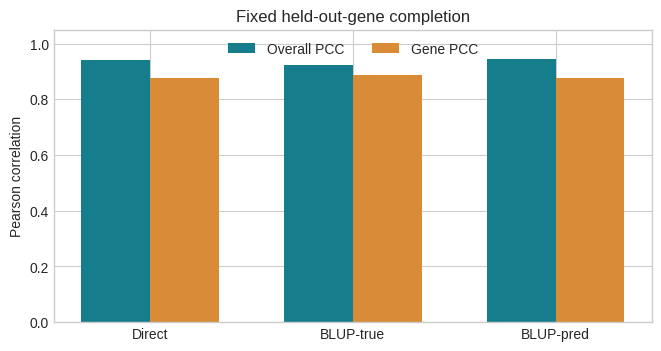

In [6]:
completion = evaluate_bulk_completion(
    data,
    run,
    measured_ridge=10.0,
    prediction_ridge=1.0,
)
completion_table = pd.DataFrame(completion["rows"]).set_index("Method")
display(completion_table.round(3))

fig, ax = plt.subplots(figsize=(6.5, 3.4), constrained_layout=True)
x = np.arange(len(completion_table))
width = 0.34
ax.bar(x - width / 2, completion_table["Overall PCC"], width, label="Overall PCC", color="#167d8d")
ax.bar(x + width / 2, completion_table["Gene PCC"], width, label="Gene PCC", color="#d98b38")
ax.set_xticks(x, completion_table.index)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Pearson correlation")
ax.set_title("Fixed held-out-gene completion")
ax.legend(frameon=False, ncol=2)
plt.show()

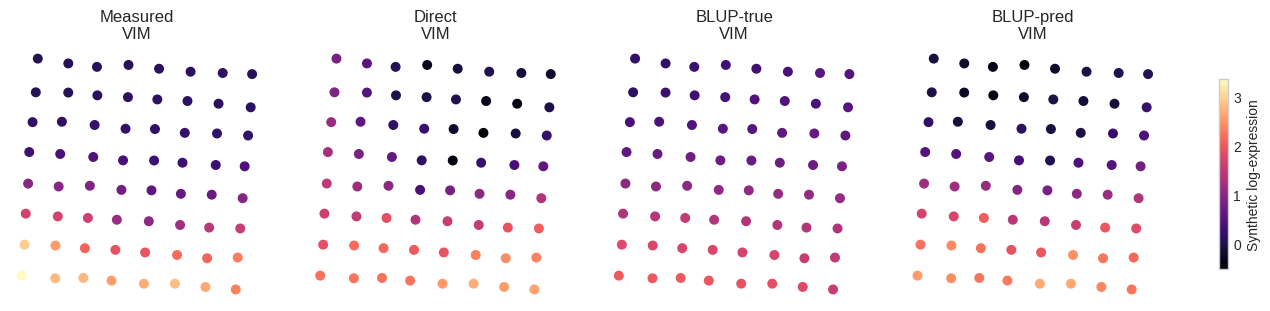

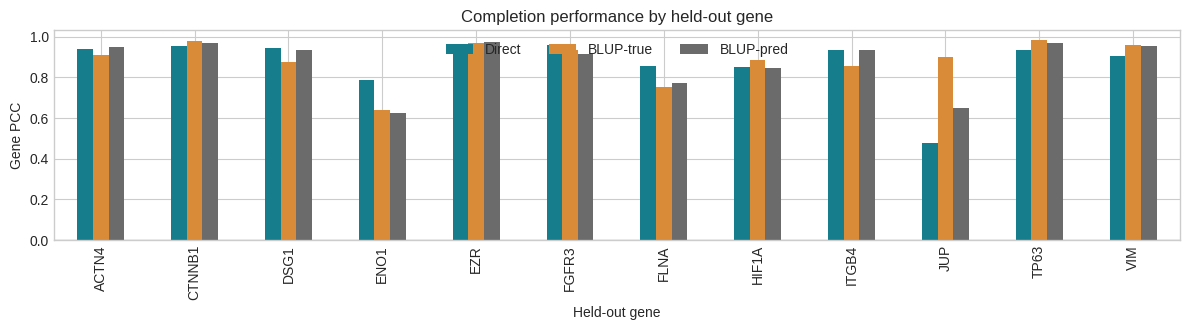

In [7]:
# Compare spatial maps for one held-out gene.
heldout_genes = data["genes"][completion["heldout"]].tolist()
heldout_position = heldout_genes.index(marker)
maps = [
    completion["target"][:, heldout_position],
    completion["predictions"]["Direct"][:, heldout_position],
    completion["predictions"]["BLUP-true"][:, heldout_position],
    completion["predictions"]["BLUP-pred"][:, heldout_position],
]
titles = ["Measured", "Direct", "BLUP-true", "BLUP-pred"]
vmin = min(values.min() for values in maps)
vmax = max(values.max() for values in maps)

fig, axes = plt.subplots(1, 4, figsize=(13, 3), constrained_layout=True)
for ax, values, title in zip(axes, maps, titles):
    scatter = ax.scatter(xy[:, 0], -xy[:, 1], c=values, cmap="magma", s=38, vmin=vmin, vmax=vmax)
    ax.set_title(f"{title}\n{marker}")
    ax.set_aspect("equal")
    ax.set_axis_off()
fig.colorbar(scatter, ax=axes, shrink=0.75, label="Synthetic log-expression")
plt.show()

# Per-gene PCC reveals information hidden by a single aggregate number.
per_gene = pd.DataFrame(completion["per_gene"], index=heldout_genes)
per_gene.plot(kind="bar", figsize=(12, 3.4), color=["#167d8d", "#d98b38", "#6b6b6b"])
plt.axhline(0, color="#333333", linewidth=0.8)
plt.ylabel("Gene PCC")
plt.xlabel("Held-out gene")
plt.title("Completion performance by held-out gene")
plt.legend(frameon=False, ncol=3)
plt.tight_layout()
plt.show()

## 5. Move from the demo to full experiments

The toy cohort validates installation and interfaces only. For full-scale
training, preprocess HEST/CellViT/H0-mini inputs as described in
`docs/preprocessing.md`, then run the modality-specific entry points:

```bash
# Visium: full leave-one-slide-out evaluation
python -m brest.train.visium --cancer COAD --sp-dir /path/to/coad_cache \
  --epochs 40 --device cuda:0 --output-json runs/coad_visium.json

# Xenium: all five spatial folds
python -m brest.train.xenium --feature-cache /path/to/features.npz \
  --metadata /path/to/cell_metadata.parquet --gene-list /path/to/genes.txt \
  --folds 0 1 2 3 4 --epochs 60 --device cuda:0
```

The benchmark bulk-completion experiment uses the same three methods shown
above, masks 100 bulk-covered genes, and reports mean ± standard deviation over
all Visium LOO folds or all five Xenium folds.

In [8]:
print("Demo completed successfully.")
print(f"Test Overall PCC: {run['test_metrics']['Overall PCC']:.3f}")
print(f"Test Gene PCC:    {run['test_metrics']['Gene PCC']:.3f}")
print(f"Completion genes: {len(completion['heldout'])}")
print("This output is a functional check, not a benchmark result.")

Demo completed successfully.
Test Overall PCC: 0.937
Test Gene PCC:    0.898
Completion genes: 12
This output is a functional check, not a benchmark result.
